## Import the required libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

C:\python\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.stats import gaussian_kde


In [2]:
import matplotlib

print(np.__version__)
print(pd.__version__)
print(sns.__version__)
print(matplotlib.__version__)

2.4.2
3.0.0
0.13.2
3.10.6


## Load and explore the dataset

In [3]:
df = pd.read_csv('data.csv',low_memory=False) # Here added low_memory to prevent season column mixed type

In [4]:
# first 5 rows
pd.set_option('display.max_columns',None) # To print all the columns
df.head(5)

,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,winner,win_by_runs,win_by_wickets,player_of_match,innings,batting_team,over,ball,batter,bowler,non_striker,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out
0,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,35.0,NaN,Yuvraj Singh,1,Sunrisers Hyderabad,0,1,DA Warner,TS Mills,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
1,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,35.0,NaN,Yuvraj Singh,1,Sunrisers Hyderabad,0,2,DA Warner,TS Mills,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
2,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,35.0,NaN,Yuvraj Singh,1,Sunrisers Hyderabad,0,3,DA Warner,TS Mills,S Dhawan,4,0,4,0,0,0,0,NaN,NaN
3,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,35.0,NaN,Yuvraj Singh,1,Sunrisers Hyderabad,0,4,DA Warner,TS Mills,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
4,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,35.0,NaN,Yuvraj Singh,1,Sunrisers Hyderabad,0,5,DA Warner,TS Mills,S Dhawan,0,2,2,2,0,0,0,NaN,NaN


In [5]:
# Last 5 rows
df.tail(5)

,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,winner,win_by_runs,win_by_wickets,player_of_match,innings,batting_team,over,ball,batter,bowler,non_striker,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out
289668,1529292,2026-05-06,2026,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Hyderabad,Sunrisers Hyderabad,Punjab Kings,Punjab Kings,field,Sunrisers Hyderabad,33.0,NaN,PJ Cummins,2,Punjab Kings,19,4,C Connolly,Shivang Kumar,Vijaykumar Vyshak,0,1,1,1,0,0,0,NaN,NaN
289669,1529292,2026-05-06,2026,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Hyderabad,Sunrisers Hyderabad,Punjab Kings,Punjab Kings,field,Sunrisers Hyderabad,33.0,NaN,PJ Cummins,2,Punjab Kings,19,5,C Connolly,Shivang Kumar,Vijaykumar Vyshak,4,0,4,0,0,0,0,NaN,NaN
289670,1529292,2026-05-06,2026,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Hyderabad,Sunrisers Hyderabad,Punjab Kings,Punjab Kings,field,Sunrisers Hyderabad,33.0,NaN,PJ Cummins,2,Punjab Kings,19,6,C Connolly,Shivang Kumar,Vijaykumar Vyshak,0,1,1,1,0,0,0,NaN,NaN
289671,1529292,2026-05-06,2026,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Hyderabad,Sunrisers Hyderabad,Punjab Kings,Punjab Kings,field,Sunrisers Hyderabad,33.0,NaN,PJ Cummins,2,Punjab Kings,19,7,C Connolly,Shivang Kumar,Vijaykumar Vyshak,6,0,6,0,0,0,0,NaN,NaN
289672,1529292,2026-05-06,2026,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Hyderabad,Sunrisers Hyderabad,Punjab Kings,Punjab Kings,field,Sunrisers Hyderabad,33.0,NaN,PJ Cummins,2,Punjab Kings,19,8,C Connolly,Shivang Kumar,Vijaykumar Vyshak,0,0,0,0,0,0,0,NaN,NaN


In [6]:
# Shape
df.shape

(289673, 30)

In [7]:
# Number of rows
df.shape[0]

289673

In [8]:
# Number of columns
df.shape[1]

30

In [9]:
# Data types of all columns
df.dtypes

match_id               int64
date                     str
season                   str
event                    str
venue                    str
city                     str
team1                    str
team2                    str
toss_winner              str
toss_decision            str
winner                   str
win_by_runs          float64
win_by_wickets       float64
player_of_match          str
innings                int64
batting_team             str
over                   int64
ball                   int64
batter                   str
bowler                   str
non_striker              str
runs_batter            int64
runs_extras            int64
runs_total             int64
extras_wides           int64
extras_noballs         int64
extras_byes            int64
extras_legbyes         int64
wicket_kind              str
wicket_player_out        str
dtype: object

In [10]:
# Information about data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 289673 entries, 0 to 289672
Data columns (total 30 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   match_id           289673 non-null  int64  
 1   date               289673 non-null  str    
 2   season             289673 non-null  str    
 3   event              289673 non-null  str    
 4   venue              289673 non-null  str    
 5   city               277276 non-null  str    
 6   team1              289673 non-null  str    
 7   team2              289673 non-null  str    
 8   toss_winner        289673 non-null  str    
 9   toss_decision      289673 non-null  str    
 10  winner             289673 non-null  str    
 11  win_by_runs        133547 non-null  float64
 12  win_by_wickets     151146 non-null  float64
 13  player_of_match    288845 non-null  str    
 14  innings            289673 non-null  int64  
 15  batting_team       289673 non-null  str    
 16  over         

----
> `Observation:`

        -> The dataset contains 289,673 ball-by-ball records from IPL matches, where each row represents a single delivery.
        -> It includes both match-level information (winner, toss result, venue, season) and ball-level statistics (runs, wickets, batter, bowler).
        -> The dataset has 30 features with a mix of categorical and numerical attributes useful for cricket analytics.
        -> Columns like toss_winner, winner, batting_team, and runs_total are directly useful for analyzing match outcomes and scoring patterns.
        -> The over column enables segmentation of innings into powerplay, middle overs, and death overs for phase-wise analysis.
        -> Batting performance can be evaluated using batter and runs_batter, while bowling performance can be analyzed using bowler and wicket_kind.
        -> Missing values are minimal and mostly present in city, win_by_runs, win_by_wickets, and wicket-related columns, which is expected in cricket datasets.
        -> Since match-level details repeat for every delivery, careful aggregation is required to avoid duplicate counting during analysis.
        
----

In [11]:
# Statistical information about data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
match_id,289673.0,965483.175453,391171.460538,335982.0,548365.0,1082626.0,1304085.0,1529292.0
win_by_runs,133547.0,30.217766,26.530801,1.0,11.0,22.0,41.0,146.0
win_by_wickets,151146.0,6.115266,1.823510,1.0,5.0,6.0,7.0,10.0
innings,289673.0,1.482793,0.502495,1.0,1.0,1.0,2.0,6.0
over,289673.0,9.190563,5.680221,0.0,4.0,9.0,14.0,19.0
ball,289673.0,3.628167,1.818353,1.0,2.0,4.0,5.0,11.0
runs_batter,289673.0,1.285477,1.659483,0.0,0.0,1.0,1.0,6.0
runs_extras,289673.0,0.068184,0.342671,0.0,0.0,0.0,0.0,7.0
runs_total,289673.0,1.353661,1.645469,0.0,0.0,1.0,1.0,7.0
extras_wides,289673.0,0.039565,0.255822,0.0,0.0,0.0,0.0,5.0


----
> `Observation:`

        -> The dataset contains 289,673 deliveries, indicating a large-scale IPL ball-by-ball dataset suitable for detailed analysis.
        -> On average, teams score 1.35 runs per ball, which reflects the high-scoring nature of T20 cricket.
        -> The median value of runs_total is 1 run per delivery, showing singles are the most frequent scoring outcome.
        -> Maximum runs recorded on a single ball are 7 runs, possible due to boundaries combined with extras.
        -> The average batter contribution per delivery is 1.28 runs, while extras contribute very minimally (0.06 runs per ball).
        -> Most overs fall around the middle phase, with the average over number being approximately 9, indicating balanced distribution across innings.
        -> The average winning margin while defending is around 30 runs, whereas chasing teams win by an average of 6 wickets.
        -> The innings column ranges up to 6 innings, suggesting the dataset may also include super overs or special match scenarios.
        -> Extras such as wides, no-balls, byes, and leg-byes occur infrequently, with wides being the most common extra type.
        -> The standard deviation values indicate significant variation in match-winning margins and scoring patterns across games.
        
----

## Data cleaning

In [12]:
# Checking duplicate rows
df.duplicated().sum()

np.int64(0)

In [13]:
# Checking missing values and its percentage of missing
total_missing = df.isnull().sum()
percentage_missing = total_missing * 100 / len(df)
missing_value_df = pd.DataFrame(data = [total_missing,percentage_missing],index=['Total','%']).T

missing_value_df

,Total,%
match_id,0.0,0.000000
date,0.0,0.000000
season,0.0,0.000000
event,0.0,0.000000
venue,0.0,0.000000
city,12397.0,4.279653
team1,0.0,0.000000
team2,0.0,0.000000
toss_winner,0.0,0.000000
toss_decision,0.0,0.000000


----
> `Observation:`

        -> The dataset contained no duplicate rows.
        -> Missing values in win_by_runs and win_by_wickets were logically present depending on the match result type (defending/chasing victory).
        -> Wicket-related columns had high null values because wickets occur only on specific deliveries.
        -> We can ignore null values of city and player_of_match
----

In [14]:
# Handling null values 

df['win_by_runs'] = df['win_by_runs'].fillna(0)
df['win_by_wickets'] = df['win_by_wickets'].fillna(0)

df['wicket_kind'] = df['wicket_kind'].fillna('No Wicket')
df['wicket_player_out'] = df['wicket_player_out'].fillna('None')

# After removing null values, verify again if null values removed or not
print('After removing null values:')
print(df.isnull().sum())

After removing null values:
match_id                 0
date                     0
season                   0
event                    0
venue                    0
city                 12397
team1                    0
team2                    0
toss_winner              0
toss_decision            0
winner                   0
win_by_runs              0
win_by_wickets           0
player_of_match        828
innings                  0
batting_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
runs_batter              0
runs_extras              0
runs_total               0
extras_wides             0
extras_noballs           0
extras_byes              0
extras_legbyes           0
wicket_kind              0
wicket_player_out        0
dtype: int64


In [15]:
# Handle data type of date
df['date'] = pd.to_datetime(df['date'])

In [16]:
# Checking unique values of season column
df['season'].unique()

<ArrowStringArray>
[   '2017',    '2018',    '2019', '2020/21',    '2021',    '2022',    '2023',
    '2024',    '2025', '2007/08',    '2009', '2009/10',    '2011',    '2012',
    '2013',    '2014',    '2015',    '2016',    '2026']
Length: 19, dtype: str

----
> `Observation:`

        -> The season column contained inconsistent formats such as integers, strings, and combined year representations (e.g. 2007/08, 2020/21).
        
----

In [17]:
# Handle season column unique values
df['season'] = df['season'].astype(str).str[:4].astype(int)

# Verify
sorted(df['season'].unique())

[np.int64(2007),
 np.int64(2009),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016),
 np.int64(2017),
 np.int64(2018),
 np.int64(2019),
 np.int64(2020),
 np.int64(2021),
 np.int64(2022),
 np.int64(2023),
 np.int64(2024),
 np.int64(2025),
 np.int64(2026)]

In [18]:
# Checking unique values of team1
sorted(df['team1'].unique())

['Chennai Super Kings',
 'Deccan Chargers',
 'Delhi Capitals',
 'Delhi Daredevils',
 'Gujarat Lions',
 'Gujarat Titans',
 'Kings XI Punjab',
 'Kochi Tuskers Kerala',
 'Kolkata Knight Riders',
 'Lucknow Super Giants',
 'Mumbai Indians',
 'Pune Warriors',
 'Punjab Kings',
 'Rajasthan Royals',
 'Rising Pune Supergiant',
 'Rising Pune Supergiants',
 'Royal Challengers Bangalore',
 'Royal Challengers Bengaluru',
 'Sunrisers Hyderabad']

----
> `Observation:`

        -> Several IPL franchises appeared under different names due to rebranding across seasons.
        -> Team names were standardized to maintain consistency in team-wise and match outcome analysis.
        -> Examples include replacing Delhi Daredevils with Delhi Capitals and Kings XI Punjab with Punjab Kings.
        
----

In [19]:
# Handle unique values of team1,team2,toss_winner,winner,batting_team

team_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
}

team_cols = ['team1', 'team2', 'toss_winner', 'winner', 'batting_team']

for col in team_cols:
    df[col] = df[col].replace(team_map)

# Verfiy
sorted(df['team1'].unique())

['Chennai Super Kings',
 'Deccan Chargers',
 'Delhi Capitals',
 'Gujarat Lions',
 'Gujarat Titans',
 'Kochi Tuskers Kerala',
 'Kolkata Knight Riders',
 'Lucknow Super Giants',
 'Mumbai Indians',
 'Pune Warriors',
 'Punjab Kings',
 'Rajasthan Royals',
 'Rising Pune Supergiant',
 'Royal Challengers Bengaluru',
 'Sunrisers Hyderabad']

In [20]:
# Checking unique values of wicket types
df['wicket_kind'].unique()

<ArrowStringArray>
[            'No Wicket',                'caught',                'bowled',
               'run out',                   'lbw',     'caught and bowled',
               'stumped',          'retired hurt',            'hit wicket',
 'obstructing the field',           'retired out']
Length: 11, dtype: str

In [21]:
# Checking unique values of over column
df['over'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

----
> `Observation:`

        -> The over column ranged from 0 to 19, confirming that the dataset uses zero-indexed over numbering.
        -> Overs should be categorized into Powerplay (0–5), Middle Overs (6–14), and Death Overs (15–19) for phase-wise scoring analysis.
        
----

In [22]:
# Check unique values of innings column
df['innings'].unique()

array([1, 2, 3, 4, 5, 6])

----
> `Observation:`

        -> The innings column contained values ranging from 1 to 6, indicating the presence of super overs or special match scenarios in addition to regular two-innings matches.
        
----

In [23]:
# Check unique values of winner column
df['winner'].unique()

<ArrowStringArray>
[        'Sunrisers Hyderabad',      'Rising Pune Supergiant',
       'Kolkata Knight Riders',                'Punjab Kings',
 'Royal Challengers Bengaluru',              'Mumbai Indians',
              'Delhi Capitals',               'Gujarat Lions',
                         'tie',         'Chennai Super Kings',
            'Rajasthan Royals',                   'no result',
              'Gujarat Titans',        'Lucknow Super Giants',
             'Deccan Chargers',               'Pune Warriors',
        'Kochi Tuskers Kerala']
Length: 17, dtype: str

----
> `Observation:`

        -> The winner column included special match outcomes such as tie and no result in addition to regular team names.
        -> These outcomes require separate handling during match result analysis.
        
----

## Feature Engineering

In [24]:
# Remove non result matches
df = df[ ~df['winner'].isin(['tie', 'no result']) ]

In [25]:
# Remove super overs / extra innings
df = df[df['innings'] <= 2]

In [26]:
# Our dataset is ball level i.e. it is showing row as per ball but for toss analysis we will require one row per match. Therefore we will create another dataframe on the basis of match
match_df = df.drop_duplicates(subset='match_id').copy()

In [27]:
# Toss winner indicator feature
match_df['toss_match_win'] = (
    match_df['toss_winner'] == match_df['winner']
)

In [28]:
# Dividing whole over into different phases like powerplay, middle overs, death overs
def get_phase(over):
    if over <= 5:
        return 'Powerplay'
    elif over <= 14:
        return 'Middle Overs'
    else:
        return 'Death Overs'

df['phase'] = df['over'].apply(get_phase)

In [29]:
# winner/loser team indicator
df['match_winner'] = (
    df['batting_team'] == df['winner']
)

# True => batting team won
# False => batting team lost

## Analysis

### Toss Winner vs Match Winner Analysis

In [30]:
# Computing required statistics

toss_stats = (
    match_df['toss_match_win']
    .value_counts(normalize=True) * 100
)

toss_stats

toss_match_win
True     51.550712
False    48.449288
Name: proportion, dtype: float64

In [31]:
# Convert labels for visualization 

toss_chart = toss_stats.reset_index()

toss_chart.columns = ['Result', 'Win Percentage']

toss_chart['Result'] = toss_chart['Result'].map({
    True: 'Toss Winner Won',
    False: 'Toss Loser Won'
})

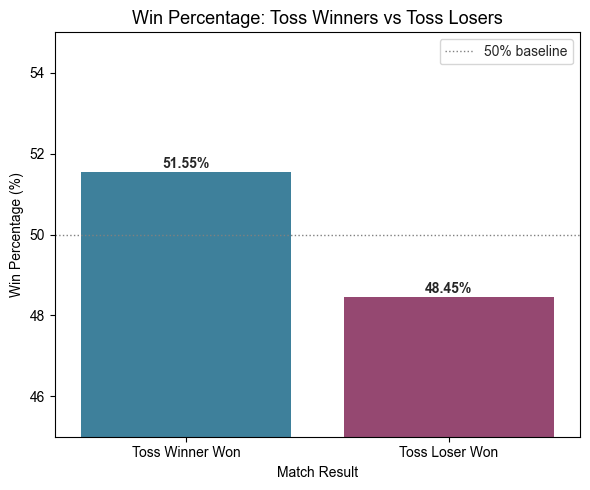

In [32]:
plt.figure(figsize=(6,5))

colors = ['#2E86AB' if r == 'Toss Winner Won' else '#A23B72' for r in toss_chart['Result']]

sns.barplot(
    data=toss_chart,
    x='Result',
    y='Win Percentage',
    hue='Result',
    palette=colors,
    legend=False
)
sns.set_style("whitegrid")

plt.title('Win Percentage: Toss Winners vs Toss Losers', fontsize=13)
plt.xlabel('Match Result')
plt.ylabel('Win Percentage (%)')
plt.ylim(45, 55)
plt.axhline(50, color='gray', linestyle=':', linewidth=1, label='50% baseline')
plt.legend()

for index, value in enumerate(toss_chart['Win Percentage']):
    plt.text(index, value + 0.1, f'{value:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_toss_win_rate.png', bbox_inches='tight', dpi=150)
plt.show()

----
> `Observation:`

    -> Teams winning the toss won approximately 51.55% of matches, while toss losers still won 48.45% of matches.
    -> The difference is very small, suggesting that winning the toss provides only a slight advantage in IPL matches.
    -> Match performance and gameplay execution appear to influence outcomes more strongly than the toss itself.
    
----

### Phase wise Runs analysis

In [33]:
# Total phase runs per team per match
phase_totals = (
    df.groupby(
        ['match_id', 'batting_team', 'phase', 'match_winner']
    )['runs_total']
    .sum()
    .reset_index()
)

phase_totals.head(5)

,match_id,batting_team,phase,match_winner,runs_total
0,335982,Kolkata Knight Riders,Death Overs,True,68
1,335982,Kolkata Knight Riders,Middle Overs,True,93
2,335982,Kolkata Knight Riders,Powerplay,True,61
3,335982,Royal Challengers Bengaluru,Death Overs,False,1
4,335982,Royal Challengers Bengaluru,Middle Overs,False,55


In [34]:
# Average phase runs
phase_avg = (
    phase_totals.groupby(['phase', 'match_winner'])['runs_total']
    .mean()
    .reset_index()
)

phase_avg

,phase,match_winner,runs_total
0,Death Overs,False,43.211473
1,Death Overs,True,47.240036
2,Middle Overs,False,66.547819
3,Middle Overs,True,74.332772
4,Powerplay,False,45.305951
5,Powerplay,True,51.291702


In [35]:
# Rename labels
phase_avg['match_winner'] = phase_avg['match_winner'].map({
    True: 'Winning Team',
    False: 'Losing Team'
})

phase_avg

,phase,match_winner,runs_total
0,Death Overs,Losing Team,43.211473
1,Death Overs,Winning Team,47.240036
2,Middle Overs,Losing Team,66.547819
3,Middle Overs,Winning Team,74.332772
4,Powerplay,Losing Team,45.305951
5,Powerplay,Winning Team,51.291702


In [36]:
phase_avg['phase'] = phase_avg['phase'].replace({
    'Powerplay': 'Powerplay (0-5)',
    'Middle Overs': 'Middle Overs (6-14)',
    'Death Overs': 'Death Overs (15-19)'
})

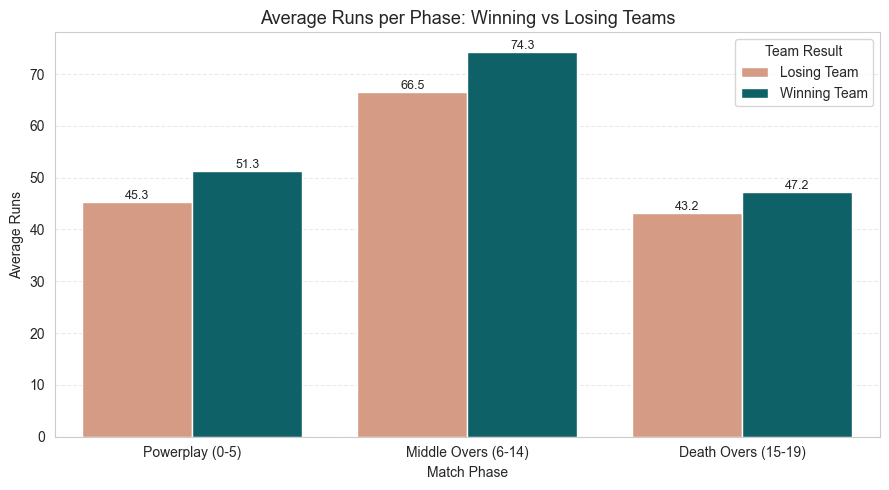

In [37]:
phase_order = ['Powerplay (0-5)', 'Middle Overs (6-14)', 'Death Overs (15-19)']

plt.figure(figsize=(9,5))

sns.barplot(
    data=phase_avg,
    x='phase',
    y='runs_total',
    hue='match_winner',
    order=phase_order,
    palette={'Winning Team': '#006D77', 'Losing Team': '#E29578'}
)

plt.title('Average Runs per Phase: Winning vs Losing Teams', fontsize=13)
plt.xlabel('Match Phase')
plt.ylabel('Average Runs')
plt.legend(title='Team Result')

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f', fontsize=9)
    
plt.grid(axis='y', linestyle='--', alpha=0.4)
sns.set_style("whitegrid")

plt.tight_layout()
plt.savefig('chart2_phase_runs.png', bbox_inches='tight', dpi=150)
plt.show()


----
> `Observation:`

        -> Winning teams scored more runs than losing teams in every phase of the innings.
        -> The highest scoring phase for both teams was the Middle Overs, where winning teams averaged approximately 74 runs compared to 66 runs for losing teams.
        -> The Powerplay also showed a noticeable difference, with winning teams scoring around 6 more runs on average.
        -> Although the Death Overs had lower total runs because of fewer overs, winning teams still maintained a scoring advantage.
        -> Overall, consistent scoring throughout all phases contributed more to match victories than dominance in only one specific phase.

> ` The analysis showed that winning teams consistently outperformed losing teams across all phases, with the middle overs contributing the largest scoring difference in IPL matches. `
----

### Top 5 batters and Top 5 bowlers 

In [38]:
# Including last 5 seasons includes 2021-25 because 2026 does not contain whole data as it is currently ongoing
last_five_df = df[df['season'].between(2021, 2025)]

In [39]:
# Top 5 batters by runs in last 5 seasons
top_batters = (
    last_five_df.groupby('batter')['runs_batter']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

top_batters.columns = ['Batter', 'Runs']
top_batters

,Batter,Runs
0,Shubman Gill,2927
1,V Kohli,2783
2,KL Rahul,2527
3,F du Plessis,2468
4,JC Buttler,2406


In [40]:
# Creating valid wickets of bowlers because it contain wickets like retired_hurt, retired_out, no wicket, obstructing the field, runout which are not possible wickets by bowlers

valid_wickets = [
    'caught',
    'bowled',
    'lbw',
    'caught and bowled',
    'stumped',
    'hit wicket'
]

bowler_df = last_five_df[
    last_five_df['wicket_kind'].isin(valid_wickets)
]

In [41]:
# Top 5 bowlers by wickets in last 5 seasons
top_bowlers = (
    bowler_df.groupby('bowler')['wicket_kind']
    .count()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

top_bowlers.columns = ['Bowler', 'Wickets']
top_bowlers

,Bowler,Wickets
0,HV Patel,104
1,YS Chahal,100
2,Arshdeep Singh,85
3,Rashid Khan,82
4,CV Varun,81


In [42]:
# Combine into final table

final_table = pd.concat(
    [top_batters, top_bowlers],
    axis=1
)

final_table

,Batter,Runs,Bowler,Wickets
0,Shubman Gill,2927,HV Patel,104
1,V Kohli,2783,YS Chahal,100
2,KL Rahul,2527,Arshdeep Singh,85
3,F du Plessis,2468,Rashid Khan,82
4,JC Buttler,2406,CV Varun,81


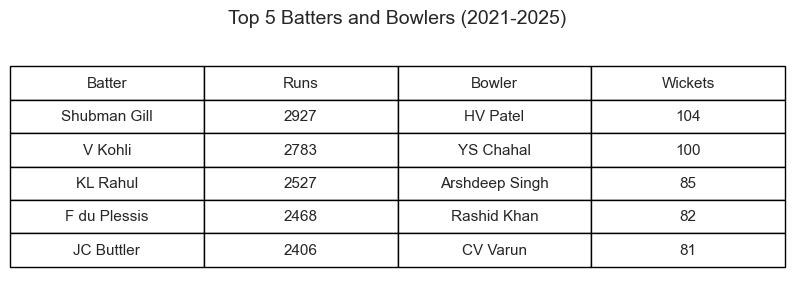

In [43]:
# Create figure
fig, ax = plt.subplots(figsize=(10,3))

# Hide axes
ax.axis('off')

# Create table
table = ax.table(
    cellText=final_table.values,
    colLabels=final_table.columns,
    cellLoc='center',
    loc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

# Title
plt.title('Top 5 Batters and Bowlers (2021-2025)', fontsize=14, pad=20)
plt.savefig('chart3_top_performers.png', bbox_inches='tight', dpi=150)
plt.show()

----
> `Observation:`

        -> Shubman Gill emerged as the highest run-scorer across the last five IPL seasons with 2927 runs.
        -> Virat Kohli and KL Rahul also maintained highly consistent batting performances.
        -> Among bowlers, Harshal Patel recorded the highest wickets tally with 104 wickets.
        -> Yuzvendra Chahal and Rashid Khan were also among the most successful wicket-takers during this period.
        -> The table highlights the dominance of consistent top-order batters and specialist T20 bowlers in recent IPL seasons.
        
----

### Average Wickets Lost per Innings Phase: Winning vs Losing Teams

In [44]:
# Create wicket indicator
df['is_wicket'] = df['wicket_kind'].apply(
    lambda x: 0 if x == 'No Wicket' else 1
)

In [45]:
# Total wickets lost per phase per match
phase_wickets = (
    df.groupby(
        ['match_id', 'batting_team', 'phase', 'match_winner']
    )['is_wicket']
    .sum()
    .reset_index()
)

In [46]:
# Average wickets lost
phase_wicket_avg = (
    phase_wickets.groupby(['phase', 'match_winner'])['is_wicket']
    .mean()
    .reset_index()
)


In [47]:
# Replace labels
phase_wicket_avg['match_winner'] = phase_wicket_avg['match_winner'].map({
    True: 'Winning Team',
    False: 'Losing Team'
})

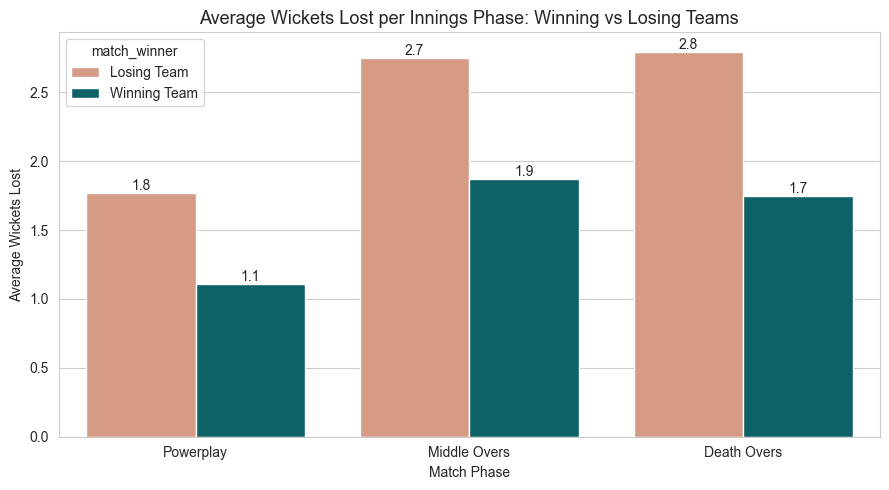

In [48]:
phase_order = ['Powerplay', 'Middle Overs', 'Death Overs']

plt.figure(figsize=(9,5))

sns.barplot(
    data=phase_wicket_avg,
    x='phase',
    y='is_wicket',
    hue='match_winner',
    order=phase_order,
    palette={'Winning Team': '#006D77', 'Losing Team': '#E29578'}
)

plt.title('Average Wickets Lost per Innings Phase: Winning vs Losing Teams',fontsize=13)
plt.xlabel('Match Phase')
plt.ylabel('Average Wickets Lost')

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f')

plt.tight_layout()
plt.savefig('chart4_wickets_per_phase.png', bbox_inches='tight', dpi=150)

plt.show()

----
> `Observation:`

        -> Losing teams consistently lost more wickets than winning teams across all innings phases.
        -> The biggest wicket gap appeared during the Death Overs, where losing teams lost nearly 2.8 wickets on average compared to 1.7 wickets for winning teams.
        -> Winning teams maintained better batting stability, especially in the middle and death overs, allowing them to preserve momentum and finish innings more effectively.
        -> The chart suggests that avoiding collapses in later stages of the innings is a key factor in IPL victories.
        
----

### Dot Ball Percentage: Winning vs Losing Teams

In [49]:
df['dot_ball'] = (df['runs_total'] == 0).astype(int)

In [50]:
dot_ball_stats = (
    df.groupby('match_winner')['dot_ball']
    .mean()
    .reset_index()
)

# Convert to percentage
dot_ball_stats['dot_ball'] = dot_ball_stats['dot_ball'] * 100

# Rename labels
dot_ball_stats['match_winner'] = dot_ball_stats['match_winner'].map({
    True: 'Winning Team',
    False: 'Losing Team'
})

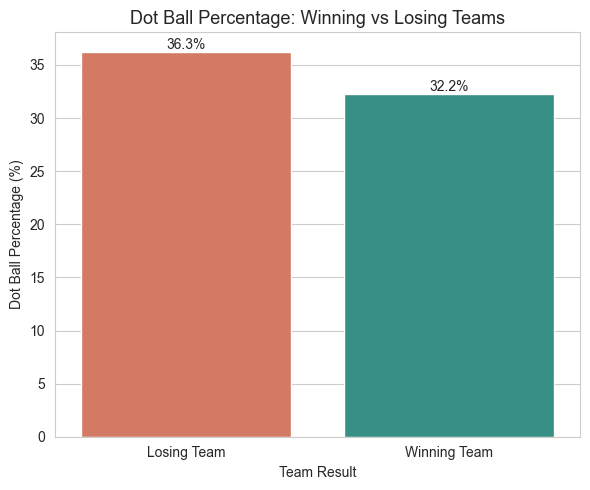

In [51]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=dot_ball_stats,
    x='match_winner',
    y='dot_ball',
    hue='match_winner',
    palette={
        'Winning Team': '#2A9D8F',
        'Losing Team': '#E76F51'
    },
    legend=False
)

plt.title('Dot Ball Percentage: Winning vs Losing Teams', fontsize=13)
plt.xlabel('Team Result')
plt.ylabel('Dot Ball Percentage (%)')

# Add labels
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.savefig('chart5_dot_ball_percentage.png', bbox_inches='tight', dpi=150)

plt.show()

----
> `Observation:`

        -> Losing teams recorded a higher dot-ball percentage (36.3%) compared to winning teams (32.2%).
        -> This indicates that winning teams rotated strike more effectively and maintained scoring momentum throughout the innings.
        -> Even a small reduction in dot balls had a noticeable impact on match outcomes, highlighting the importance of consistent scoring in T20 cricket.
        -> The analysis reinforces that pressure created through dot balls often contributes to wickets and slower scoring rates for losing teams.
        
----

---
## Summary

| Question | Finding |
|---|---|
| Does the toss help? | Only slightly, toss winners won 51.5% of matches, indicating minimal advantage |
| Most impactful phase? |Middle overs (6–14), where winning teams outscored losing teams by around 8 runs on average |
| Wicket-loss pattern | Losing teams consistently lost more wickets across all phases, especially during the death overs |
|Dot ball impact | Losing teams recorded a higher dot-ball percentage (36.3%) compared to winning teams (32.2%) |
| Top batter (2021–25)? | Shubman Gill ; 2,927 runs |
| Top bowler (2021–25)? | Harshal Patel ; 104 wickets |

---

----
## One sentence that genuinely surprised me:

> `I expected the death overs to have the greatest impact on match outcomes, but the analysis revealed that the middle overs (6–14) created the largest scoring gap between winning and losing teams winners averaged 8 more runs than losers in the middle overs, compared to only 4 more in the death overs. In IPL, it's not the finisher but the builder who wins the match.`

----

----

> `Conclusion:`

`The analysis revealed that winning the toss has only a minor impact on IPL match outcomes, whereas consistent batting performance across all innings phases especially during the middle overs plays a much more significant role in determining victory. Winning teams also maintained better momentum by losing fewer wickets and playing fewer dot balls throughout the innings. Additionally, players like Shubman Gill and Harshal Patel demonstrated exceptional consistency across recent IPL seasons.`

----